# Kinematics Error Propagation

In [2]:
from smode_import import *

In [7]:
time_crossing_intervals = [
    ['2023-04-20T03:20:00', '2023-04-20T05:00:00'],
    ['2023-04-20T21:00:00', '2023-04-20T23:00:00'],
    ['2023-04-21T16:40:00', '2023-04-21T17:25:00'],
    ['2023-04-21T18:30:00', '2023-04-21T19:26:00'],
    ['2023-04-22T21:55:00', '2023-04-22T23:40:00'],
    ['2023-04-24T21:40:00', '2023-04-24T23:30:00'],
    ['2023-04-24T21:40:00', '2023-04-24T23:30:00']
] # time we crossed the eddy

times_dopplerscatt=['2023-04-19T20','2023-04-20T20',
                  '2023-04-21T15','2023-04-21T21',
                  '2023-04-22T20','2023-04-24T20',]
orientations = ['zonal','meridional','meridional','zonal','meridional']
reverse=[False,False,False,False,True]

In [84]:
# Div and Vor error
sig_u = 0.05 # m s-1
dx = 200 # m
sig_gaussian = 5 # gaussian filter used for kinematic
L_eff = 2000# m dx * sig_gaussian # m
sig_kin = sig_u / L_eff # div and vor error are the same
sig_kin_f_norm = sig_kin / f
sig_kin_f_norm

np.float64(0.28483566824414147)

meridional


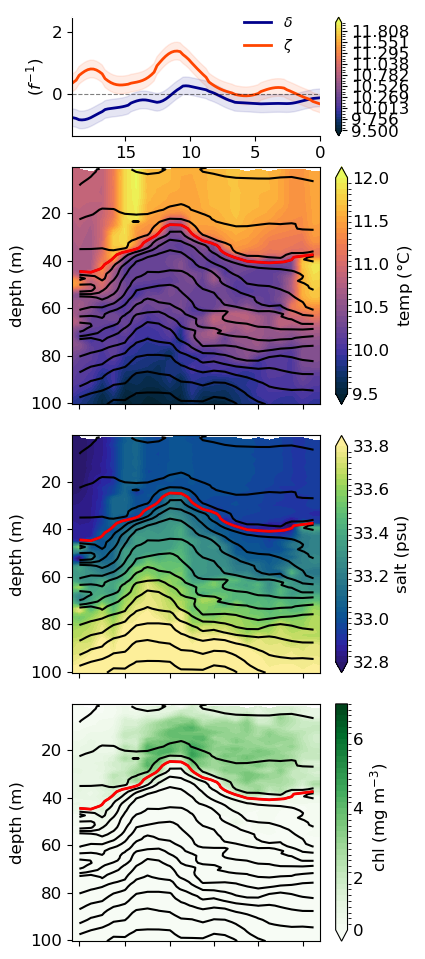

In [85]:
from scipy.ndimage import gaussian_filter

# MVP & Dopplerscatt datasets
da = xr.open_dataset('../MVP.nc')
da['rho'] = da.rho.where(da.salt >= 32.5) # keep density where salt < 32.5
ds = xr.open_dataset('../dopplerscatt_gridded.nc') # dopplerscatt

# Div and Vor error

# Select transect
i = 4
time_start = (datetime.strptime(time_crossing_intervals[i][0], '%Y-%m-%dT%H:%M:%S') - timedelta(minutes=0)).strftime('%Y-%m-%dT%H:%M:%S')
time_end = (datetime.strptime(time_crossing_intervals[i][1], '%Y-%m-%dT%H:%M:%S') + timedelta(minutes=0)).strftime('%Y-%m-%dT%H:%M:%S')

da_ = da.sel(time=slice(time_start, time_end))
lon0,lon1=da_.lon.min().values,da_.lon.max().values
lat0,lat1=da_.lat.min().values,da_.lat.max().values

# Panel 1: vorticity & divergence
# Plot
fig, ax = plt.subplots(4,1,figsize=(4,12),
                       gridspec_kw={'height_ratios': [0.5, 1, 1, 1,],'hspace': 0.15})
plt.rcParams.update({'font.size': 12})
axis=ax[0]

time_start = times_dopplerscatt[i]
time_end = (datetime.strptime(time_start, '%Y-%m-%dT%H') + timedelta(hours=10)).strftime('%Y-%m-%dT%H')
ds_ = ds.sel(time=slice(time_start, time_end)).isel(time=0) # div/vor
#w_E = ds_ekman.sel(time=slice(time_start,time_end)).isel(time=0) # Ekman Transport
f = coriolis_parameter(37)

tick_dist_km = np.arange(0, 50, 5)
print(orientations[i])
if orientations[i]=='meridional':
    div = (ds_.sel(lon=lon0, method='nearest').divergence / f)
    vor = (ds_.sel(lon=lon0, method='nearest').vorticity / f)
    
    l1,=div.plot(label=r'$\delta$', color='darkblue', linewidth=2, ax=axis)
    l2,=vor.plot(label=r'$\zeta$', color='orangered', linewidth=2, ax=axis)
    ticks = lat0 + tick_dist_km / 111

    # add shading error
    axis.fill_between(div.lat, div - sig_kin_f_norm, div + sig_kin_f_norm, edgecolor='none', color='darkblue', alpha=0.1)
    axis.fill_between(vor.lat, vor - sig_kin_f_norm, vor + sig_kin_f_norm, edgecolor='none', color='orangered', alpha=0.1)
    
    
elif orientations[i]=='zonal':
    div = (ds_.sel(lat=lat0, method='nearest').divergence / f)
    vor = (ds_.sel(lat=lat0, method='nearest').vorticity / f)
    
    l1,=div.plot(label=r'$\delta/f$', color='darkblue', linewidth=2, ax=axis)
    l2,=vor.plot(label=r'$\zeta/f$', color='orangered', linewidth=2, ax=axis)
    phi = np.mean(da_.lat.values)
    km_per_deg_lon = 111.32 * np.cos(np.deg2rad(phi))
    ticks = (lon_subset - lon0) * km_per_deg_lon

    # add shading error
    axis.fill_between(div.lon, div - sig_kin_f_norm, div + sig_kin_f_norm, edgecolor='none', color='darkblue', alpha=1)
    axis.fill_between(vor.lon, vor - sig_kin_f_norm, vor + sig_kin_f_norm, edgecolor='none', color='orangered', alpha=1)

# x-ticks in distances [km]
axis.set_xticks(ticks)
axis.set_xticklabels(tick_dist_km)
axis.set_xlabel("Distance (km)")
if orientations[i]=='meridional': axis.set_xlim(lat0, lat1)
if orientations[i]=='zonal': axis.set_xlim(lon0, lon1)
axis.set_ylabel(r'($f^{-1}$)')
axis.spines['top'].set_color('w'); axis.spines['right'].set_color('w')
axis.legend(bbox_to_anchor=(0.94, 1.12), fontsize=10, loc='upper right',frameon=False)
axis.axhline(0, color='k', linestyle='--', alpha=0.5, linewidth=0.8)
if reverse[i]: axis.invert_xaxis()

# Transect panels: temp, salt, chl
n=40
p_temp=da.temp.plot.contourf(levels=np.linspace(9.5,12.,n),ax=ax[1],cmap=cm.thermal,x='time', add_colorbar=True)
p_salt=da.salt.plot.contourf(levels=np.linspace(32.8,33.8,n),ax=ax[2],cmap=cm.haline,x='time', add_colorbar=True)
p_chl =da.chla.plot.contourf(levels=np.linspace(0.5,7,n),ax=ax[3],cmap='Greens',x='time', add_colorbar=True)

# set cbar ticks
for cbar in [p_temp.colorbar, p_salt.colorbar, p_chl.colorbar]:
    cbar.ax.tick_params(length=0)
p_temp.colorbar.set_ticks(np.arange(9.5,12.5,0.5)); p_temp.colorbar.set_label(r'temp ($\degree $C)')
p_salt.colorbar.set_ticks(np.arange(32.8,33.9,0.2)); p_salt.colorbar.set_label('salt (psu)')
p_chl.colorbar.set_ticks(np.arange(0,8,2)); p_chl.colorbar.set_label(r'chl (mg m$^{-3}$)')
# add colorbar to ax0 for shape
plt.colorbar(p_temp,ax=ax[0])

# set x-limits
dt=0. #hours
for axis in ax[1::]:
    axis.set_xlim(pd.Timestamp(time_crossing_intervals[i][0])- timedelta(hours=dt),
                pd.Timestamp(time_crossing_intervals[i][1])+ timedelta(hours=dt))

# apply gaussian filter to density contours
rho_smoothed = da_.rho.rolling(time=3, center=True, min_periods=1).mean()
for axis in ax[1::]:
    #da_.rho.plot.contour(levels=20,x='time',colors='k',linewidths=0.8,ax=axis)
    rho_smoothed.plot.contour(levels=20,x='time',colors='k',linewidths=1.5,ax=axis)
    rho_smoothed.plot.contour(levels=[1025.3], x='time', colors='r',linewidths=2,ax=axis)
    axis.set_xlabel('')
    axis.invert_yaxis()
    axis.set_xticks(da_.time[::4], '')

# y-label
for axis in ax[1::]:
    axis.set_ylabel('depth (m)')

# remove titles
for axis in ax: axis.set_title('')

plt.savefig('../figures/Fig1defgh-error.pdf',transparent=True,bbox_inches='tight') 
plt.show()